In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, VGG16, VGG19, InceptionV3
from tensorflow.keras import mixed_precision

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils import compute_class_weight, resample
from sklearn.model_selection import train_test_split
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

mixed_precision.set_global_policy('mixed_float16')

print("GPU:", tf.config.list_physical_devices('GPU'))

E0000 00:00:1775678174.715836    1014 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775678174.723994    1014 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775678174.745496    1014 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775678174.745522    1014 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775678174.745525    1014 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775678174.745527    1014 computation_placer.cc:177] computation placer already registered. Please check linka

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
IMAGES_PATH = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset"
ANNOTATIONS_PATH = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations"

In [3]:
data = []

for embryo_folder in os.listdir(IMAGES_PATH):
    embryo_path = os.path.join(IMAGES_PATH, embryo_folder)
    f0_path = os.path.join(embryo_path, "F0")
    csv_file = os.path.join(ANNOTATIONS_PATH, embryo_folder + "_phases.csv")

    if not os.path.exists(f0_path) or not os.path.exists(csv_file):
        continue

    df = pd.read_csv(csv_file, header=None, names=["phase", "start", "end"])
    images = sorted(os.listdir(f0_path))

    for _, row in df.iterrows():
        for i in range(int(row["start"]), int(row["end"]) + 1):
            if i < len(images):
                data.append([os.path.join(f0_path, images[i]), row["phase"]])


In [4]:
# STEP 1: Create df_final (same as before)

df_final = pd.DataFrame(data, columns=["filename", "class"])

# STEP 2: MAP CLASSES
mapping = {
    'tPB2': 'early', 'tPNa': 'early', 'tPNf': 'early',
    't2': 'mid', 't3': 'mid', 't4': 'mid',
    't5': 'late', 't6': 'late', 't7': 'late', 't8': 'late'
}

df_final['class'] = df_final['class'].map(mapping)
df_final = df_final.dropna()

In [5]:
bad_files = []
good_files = []
good_labels = []

import tensorflow as tf

print("TensorFlow strict cleaning started...")

for path, label in zip(df_final['filename'], df_final['class']):
    try:
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)  # strict
        img = tf.image.resize(img, (224, 224))

        good_files.append(path)
        good_labels.append(label)

    except:
        bad_files.append(path)

print("Bad images (TF detected):", len(bad_files))
print("Good images:", len(good_files))

TensorFlow strict cleaning started...


I0000 00:00:1775678186.784768    1014 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775678186.789910    1014 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input file read error
Input fi

Bad images (TF detected): 4891
Good images: 48712


In [6]:
df_final = pd.DataFrame({
    "filename": good_files,
    "class": good_labels
})

print("Final clean dataset:", len(df_final))
print(df_final['class'].value_counts())

Final clean dataset: 48712
class
mid      17518
early    15608
late     15586
Name: count, dtype: int64


In [7]:
# Encode labels
class_names = sorted(df_final['class'].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}

df_final['label'] = df_final['class'].map(class_to_index)

# Split AFTER cleaning
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_final,
    test_size=0.3,
    stratify=df_final['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

NUM_CLASSES = len(class_names)

In [8]:
print("Train size:", len(train_df))
print("Expected steps:", len(train_df)//16)

Train size: 34098
Expected steps: 2131


In [9]:
train_labels = tf.keras.utils.to_categorical(train_df['label'], NUM_CLASSES)
val_labels   = tf.keras.utils.to_categorical(val_df['label'], NUM_CLASSES)
test_labels  = tf.keras.utils.to_categorical(test_df['label'], NUM_CLASSES)

In [10]:
def load_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224, 224))

    image = tf.cast(image, tf.float32)   # ✔ NO normalization

    return image, label

In [11]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df['filename'].values, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df['filename'].values, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df['filename'].values, test_labels)
)

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(16).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(16).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(16).prefetch(tf.data.AUTOTUNE)

In [12]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_pre
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_pre
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_pre
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_pre

datasets = {
    "mobilenet": (
        train_ds.map(lambda x,y:(mobilenet_pre(x),y)),
        val_ds.map(lambda x,y:(mobilenet_pre(x),y)),
        test_ds.map(lambda x,y:(mobilenet_pre(x),y))
    ),
    "vgg16": (
        train_ds.map(lambda x,y:(vgg16_pre(x),y)),
        val_ds.map(lambda x,y:(vgg16_pre(x),y)),
        test_ds.map(lambda x,y:(vgg16_pre(x),y))
    ),
    "vgg19": (
        train_ds.map(lambda x,y:(vgg19_pre(x),y)),
        val_ds.map(lambda x,y:(vgg19_pre(x),y)),
        test_ds.map(lambda x,y:(vgg19_pre(x),y))
    ),
    "googlenet": (
        train_ds.map(lambda x,y:(inception_pre(x),y)),
        val_ds.map(lambda x,y:(inception_pre(x),y)),
        test_ds.map(lambda x,y:(inception_pre(x),y))
    )
}

In [14]:
standard_loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

labels = train_df['label'].values
cw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_dict = dict(enumerate(cw))

# FIXED tensor
class_weights_tensor = tf.constant(list(class_weights_dict.values()), dtype=tf.float32)

def hybrid_loss_fn(y_true, y_pred):

    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

    weights = tf.reduce_sum(y_true * class_weights_tensor, axis=-1)

    ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

    focal = -tf.reduce_sum(
        y_true * ((1 - y_pred) ** 2.0) * tf.math.log(y_pred),
        axis=-1
    )

    return 0.5 * weights * ce + 0.5 * focal

In [16]:
def build_model(name, loss_fn):

    if name == "mobilenet":
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    elif name == "vgg16":
        base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    elif name == "vgg19":
        base = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
    else:
        base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

    base.trainable = True

    for layer in base.layers[:-30]:
     layer.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=loss_fn,
        metrics=['accuracy']
    )

    return model

In [17]:
labels = train_df['label'].values

cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights_dict = dict(enumerate(cw))

# ALSO add this (for hybrid loss)
class_weights_tensor = tf.constant(list(class_weights_dict.values()), dtype=tf.float32)

In [18]:
EPOCHS = 5
results = {}
histories = {}

for loss_name, loss_fn in {
    "standard": standard_loss,
    "hybrid": hybrid_loss_fn
}.items():

    print("\nLOSS:", loss_name)

    for name in ["mobilenet", "vgg16", "vgg19", "googlenet"]:

        print("\nTraining:", name)

        model = build_model(name, loss_fn)
        train_m, val_m, test_m = datasets[name]

        path = f"/kaggle/working/{name}_{loss_name}.weights.h5"

        if os.path.exists(path):
            model.load_weights(path)

        checkpoint = tf.keras.callbacks.ModelCheckpoint(
            path, save_best_only=True, save_weights_only=True, monitor='val_accuracy'
        )

        history = model.fit(
            train_m,
            validation_data=val_m,
            epochs=EPOCHS,
            callbacks=[checkpoint],
            class_weight=class_weights_dict,
            verbose=1
        )

        acc = model.evaluate(test_m, verbose=0)[1]

        histories[(name, loss_name)] = history
        results[(name, loss_name)] = acc

        print(f"{name} + {loss_name} → Test Acc: {acc:.4f}")


LOSS: standard

Training: mobilenet
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1775678503.600474    1075 service.cc:152] XLA service 0x7f25a80047d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775678503.600532    1075 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775678503.600539    1075 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775678505.603880    1075 c

2132/2132 ━━━━━━━━━━━━━━━━━━━━ 166s 54ms/step - accuracy: 0.6766 - loss: 0.7992 - val_accuracy: 0.7819 - val_loss: 0.6754
Epoch 2/5
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.8363 - loss: 0.5758 - val_accuracy: 0.8571 - val_loss: 0.5365
Epoch 3/5
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - accuracy: 0.8724 - loss: 0.5186 - val_accuracy: 0.8467 - val_loss: 0.5685
Epoch 4/5
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.8975 - loss: 0.4770 - val_accuracy: 0.8959 - val_loss: 0.4822
Epoch 5/5
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - accuracy: 0.9139 - loss: 0.4492 - val_accuracy: 0.9038 - val_loss: 0.4603
mobilenet + standard → Test Acc: 0.9047

Training: vgg16
Epoch 1/5
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 296s 112ms/step - accuracy: 0.3544 - loss: 1.1696 - val_accuracy: 0.3597 - val_loss: 1.0979
Epoch 2/5
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 210s 98ms/step - accuracy: 0.3564 - loss: 1.0988 - val_accuracy: 0.3597 - val_loss: 1.0985
Epoch 3/5
2132/2132 ━━━━━━━━━━━━

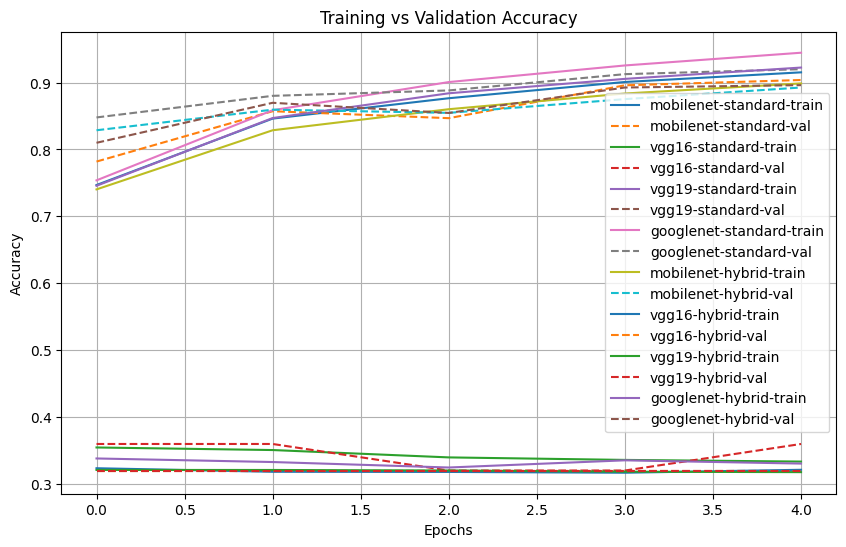

In [20]:
plt.figure(figsize=(10,6))

for key in histories:
    name, loss_type = key
    history = histories[key]

    plt.plot(
        history.history['accuracy'],
        label=f"{name}-{loss_type}-train"
    )

    plt.plot(
        history.history['val_accuracy'],
        linestyle='--',
        label=f"{name}-{loss_type}-val"
    )

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

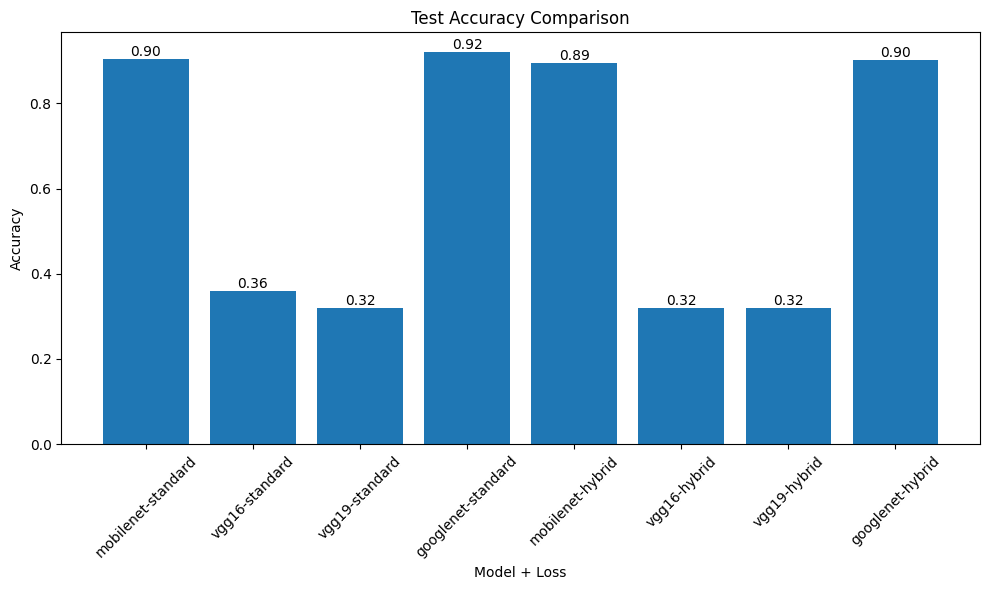

In [21]:
models = []
accuracies = []

for key in results:
    name, loss_type = key
    models.append(f"{name}-{loss_type}")
    accuracies.append(results[key])

plt.figure(figsize=(10,6))
plt.bar(models, accuracies)

plt.title("Test Accuracy Comparison")
plt.xlabel("Model + Loss")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [24]:
print("\n===== FINAL RESULTS =====\n")

for key in results:
    name, loss_type = key
    print(f"{name.upper()} + {loss_type.upper()} → Test Accuracy: {results[key]:.4f}")


===== FINAL RESULTS =====

MOBILENET + STANDARD → Test Accuracy: 0.9047
VGG16 + STANDARD → Test Accuracy: 0.3597
VGG19 + STANDARD → Test Accuracy: 0.3200
GOOGLENET + STANDARD → Test Accuracy: 0.9205
MOBILENET + HYBRID → Test Accuracy: 0.8942
VGG16 + HYBRID → Test Accuracy: 0.3200
VGG19 + HYBRID → Test Accuracy: 0.3200
GOOGLENET + HYBRID → Test Accuracy: 0.9021
